# Flamenco Palo Classifier
## Exploratory Data Analysis & Classification Model

**Dataset:** cante100 / corpusCOFLA — 100 tracks, 10 style families  
**Target classes:** soleá, seguiriya, bulería, alegrías  
**Features:** musicologically grounded audio features (Phrygian mode, vocal density, timbre, harmony)  
**References:** Castro Buendía 2014, Ojesto 2017, Fernández 2004, Asensio ESMUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Data Loading & Initial Inspection

In [2]:
DATA_PATH = Path.home() / 'Desktop' / 'cante100_features_v2.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution (all labels):')
print(df['label'].value_counts())
print(f'\nTarget classes (4-class):')
print(df['label_4class'].value_counts())

Dataset shape: (100, 57)

Class distribution (all labels):
label
fandangos             10
tientostangos         10
soleares              10
seguiriyas            10
alegrias              10
bulerias              10
cantesmineros         10
cantesamericanos      10
malaguenasgraninas    10
tonas                 10
Name: count, dtype: int64

Target classes (4-class):
label_4class
other         60
soleares      10
seguiriyas    10
alegrias      10
bulerias      10
Name: count, dtype: int64


## 2. Exploratory Data Analysis

### 2.1 Musicologically-grounded features
We start with the features designed from music theory: vocal density (`pct_voiced`), Phrygian mode indicator (`bII_energy`), Major/minor ratio (`ratio_mayor_menor`), and tempo.

In [3]:
# Focus on the 4 target classes
target = df[df['label_4class'] != 'other'].copy()

# Summary table of key musicological features
music_features = ['bII_energy', 'bVII_energy', 'ratio_mayor_menor', 
                  'f0_median_hz', 'pct_voiced', 'tempo_bpm']

summary = target.groupby('label_4class')[music_features].mean().round(3)
print("Mean values per palo — musicological features:")
print(summary.to_string())

Mean values per palo — musicological features:
              bII_energy  bVII_energy  ratio_mayor_menor  f0_median_hz  pct_voiced  tempo_bpm
label_4class                                                                                 
alegrias           0.095        0.079              1.060       199.381       0.517    158.037
bulerias           0.095        0.093              0.977       286.964       0.463    125.125
seguiriyas         0.085        0.078              1.169       189.765       0.712    104.496
soleares           0.091        0.078              1.087       247.591       0.651    130.916


### 2.2 Visualising feature distributions by palo

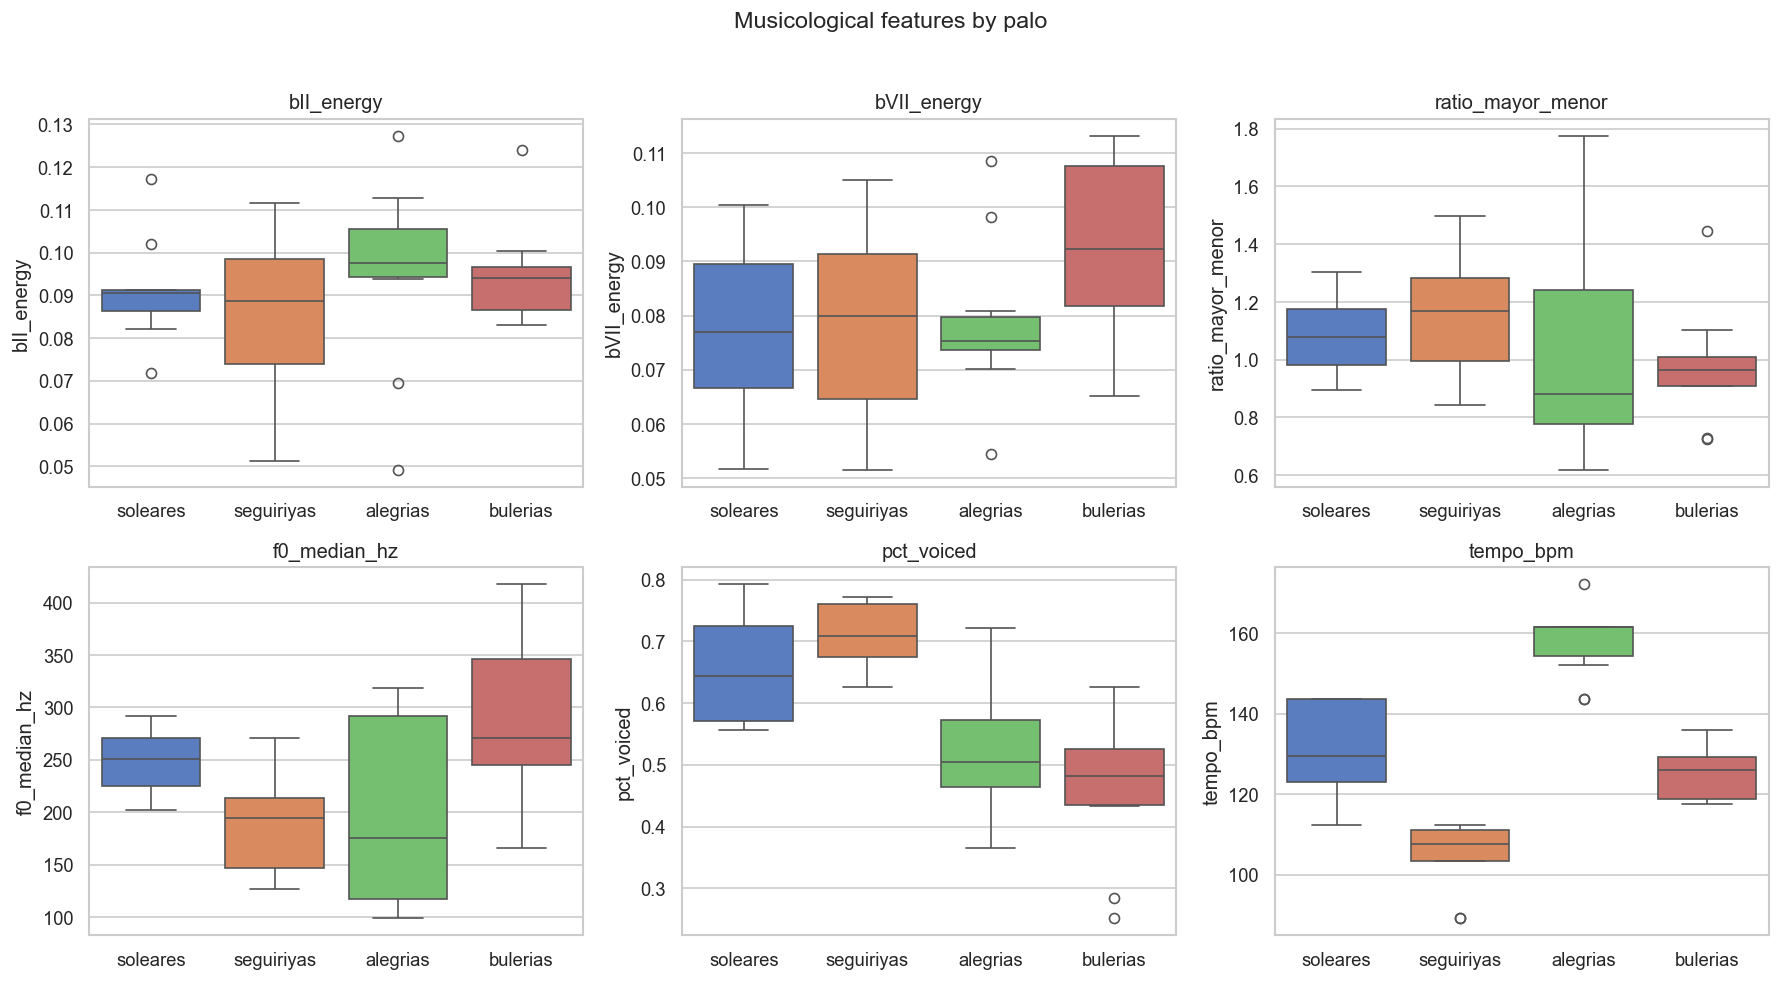

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(music_features):
    sns.boxplot(data=target, x='label_4class', y=feat, ax=axes[i],
            hue='label_4class', palette='muted', legend=False)
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.suptitle('Musicological features by palo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Mean relative chroma profile by palo
The chroma vector is rotated so that position 0 = estimated tonic. This allows cross-key comparison and reveals modal fingerprints: a Phrygian profile shows a strong bII (position 1) relative to the tonic.

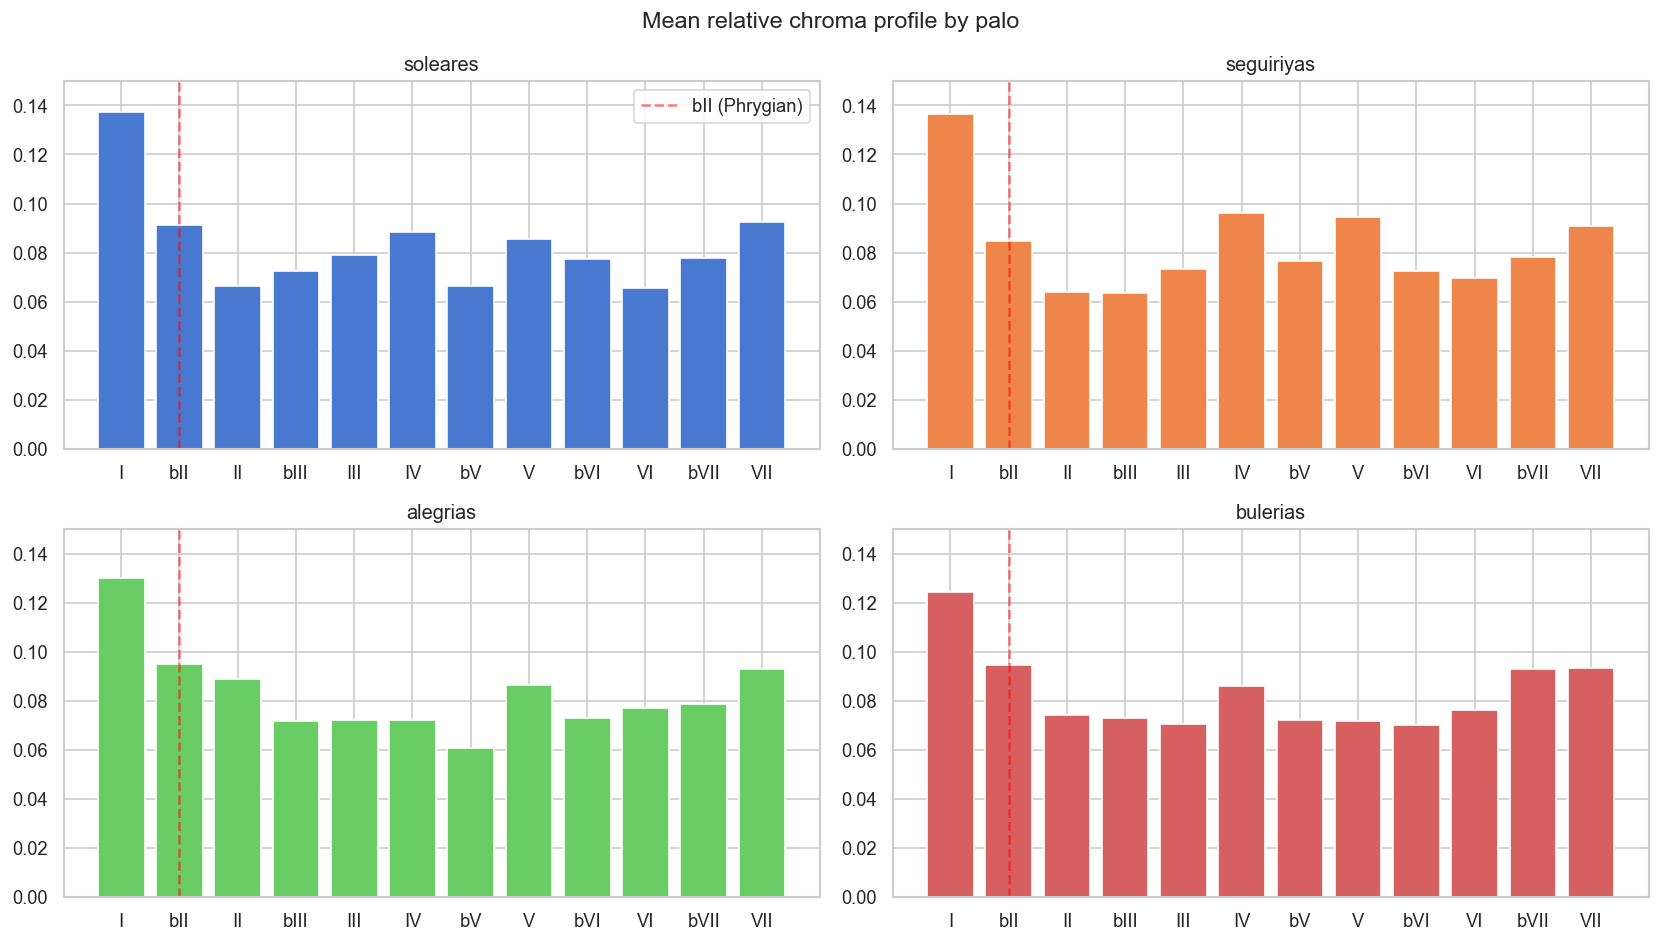

In [6]:
chroma_cols = [f'chroma_rel_{i}' for i in range(12)]
degree_labels = ['I', 'bII', 'II', 'bIII', 'III', 'IV', 'bV', 'V', 'bVI', 'VI', 'bVII', 'VII']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, palo in enumerate(['soleares', 'seguiriyas', 'alegrias', 'bulerias']):
    subset = target[target['label_4class'] == palo]
    mean_chroma = subset[chroma_cols].mean().values
    axes[i].bar(degree_labels, mean_chroma, color=sns.color_palette('muted')[i])
    axes[i].set_title(palo)
    axes[i].set_ylim(0, 0.15)
    axes[i].axvline(x=1, color='red', linestyle='--', alpha=0.5, label='bII (Phrygian)')

axes[0].legend()
plt.suptitle('Mean relative chroma profile by palo', fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Correlation heatmap
Checking for redundancy among features before model training.

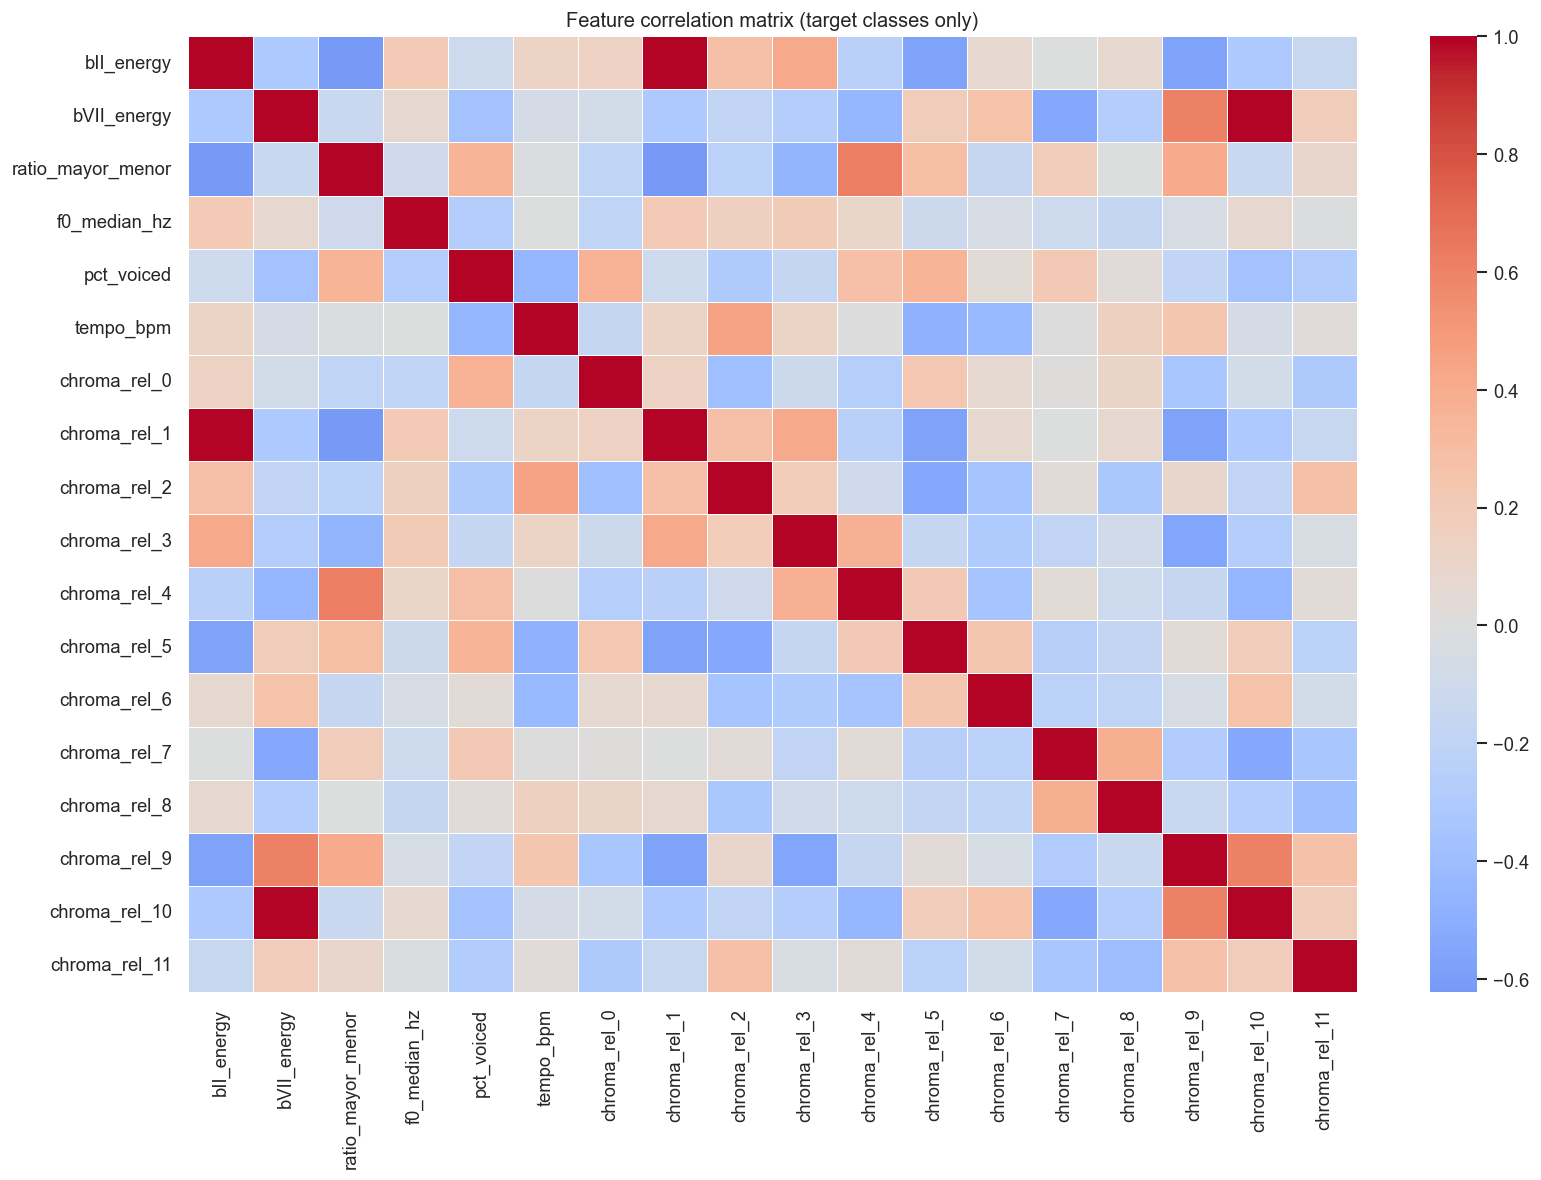

In [7]:
features_for_corr = music_features + chroma_cols
corr = target[features_for_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, 
            annot=False, linewidths=0.3)
plt.title('Feature correlation matrix (target classes only)')
plt.tight_layout()
plt.show()

## 3. Preprocessing & Model Training

### 3.1 Feature selection and train/test split

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature matrix
feature_cols = music_features + chroma_cols + \
               [f'mfcc_{i}_mean' for i in range(1, 14)] + \
               [f'mfcc_{i}_std' for i in range(1, 14)]

X = target[feature_cols]
y = target['label_4class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}, Test: {X_test_sc.shape}')
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

Train: (32, 44), Test: (8, 44)

Class distribution in test set:
label_4class
seguiriyas    2
soleares      2
alegrias      2
bulerias      2
Name: count, dtype: int64


### 3.2 Baseline model: Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred = rf.predict(X_test_sc)

print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    alegrias       1.00      0.50      0.67         2
    bulerias       0.50      1.00      0.67         2
  seguiriyas       0.67      1.00      0.80         2
    soleares       0.00      0.00      0.00         2

    accuracy                           0.62         8
   macro avg       0.54      0.62      0.53         8
weighted avg       0.54      0.62      0.53         8



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### 3.3 Confusion matrix & feature importance

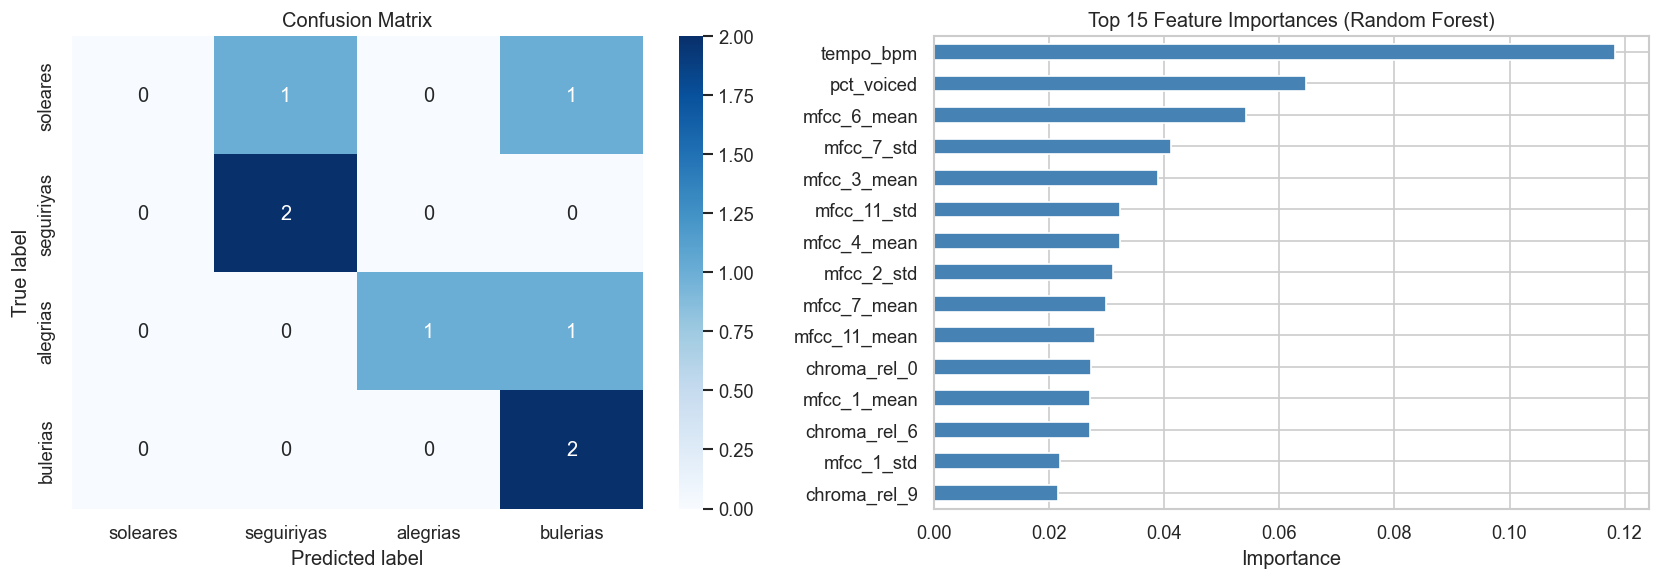

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, 
                      labels=['soleares','seguiriyas','alegrias','bulerias'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['soleares','seguiriyas','alegrias','bulerias'],
            yticklabels=['soleares','seguiriyas','alegrias','bulerias'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top15 = importances.nlargest(15)
top15.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Feature Importances (Random Forest)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### 3.4 Cross-validation
With only 40 samples, a single train/test split is unreliable. We use stratified k-fold CV to get a more robust accuracy estimate.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
print(f'CV F1-macro scores: {scores.round(3)}')
print(f'Mean: {scores.mean():.3f} ± {scores.std():.3f}')

CV F1-macro scores: [0.625 0.867 0.642 0.425 0.75 ]
Mean: 0.662 ± 0.147


## 4. Qualitative Generalisation Analysis
Model trained on all 40 target samples and applied to the full 100-track dataset to assess how the model handles unseen palos.

In [15]:
# Apply trained model to all 100 tracks
X_all = df[feature_cols]
df['predicted'] = pipe_full.predict(X_all)

print("Generalisation results — all 10 palos:")
print(pd.crosstab(df['label'], df['predicted']))

Generalisation results — all 10 palos:
predicted           alegrias  bulerias  seguiriyas  soleares
label                                                       
alegrias                  10         0           0         0
bulerias                   0        10           0         0
cantesamericanos           1         0           5         4
cantesmineros              1         0           4         5
fandangos                  4         0           2         4
malaguenasgraninas         0         0           6         4
seguiriyas                 0         0          10         0
soleares                   0         0           1         9
tientostangos              2         5           3         0
tonas                      0         0           7         3


## 5. Retraining with positional beat-cycle features (v3)
Three new features derived from the 12-beat flamenco cycle: frequency of tonic at position 10 (`freq_tonica_pos10`), frequency of bII at position 3 (`freq_bII_pos3`), and mean harmonic entropy at accent positions (`harmonic_entropy_mean`).

In [16]:
# Reload CSV v3
DATA_PATH_V3 = Path.home() / 'Desktop' / 'cante100_features_v3.csv'
df3 = pd.read_csv(DATA_PATH_V3)

new_features = ['freq_tonica_pos10', 'freq_bII_pos3', 'harmonic_entropy_mean']
print("Mean positional features by target palo:")
target3 = df3[df3['label_4class'] != 'other']
print(target3.groupby('label_4class')[new_features].mean().round(3))

Mean positional features by target palo:
              freq_tonica_pos10  freq_bII_pos3  harmonic_entropy_mean
label_4class                                                         
alegrias                  0.254          0.092                  1.821
bulerias                  0.351          0.097                  1.931
seguiriyas                0.285          0.085                  1.947
soleares                  0.277          0.135                  1.970


### 5.1 Boxplot of positional features by palo

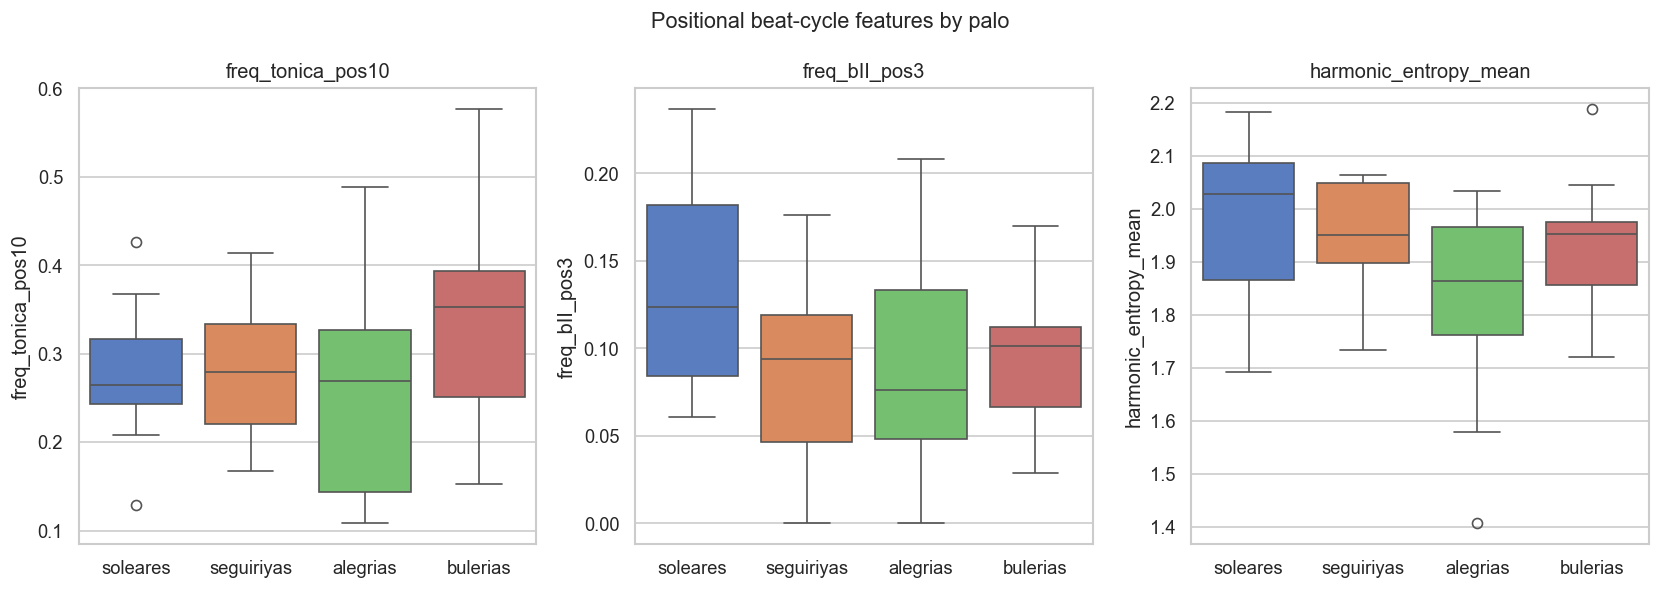

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, feat in enumerate(new_features):
    sns.boxplot(data=target3, x='label_4class', y=feat,
                hue='label_4class', palette='muted', legend=False, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.suptitle('Positional beat-cycle features by palo', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


### 5.2 Retraining with v3 features
We retrain the Random Forest adding the three positional features to the original 57-feature set (60 total) and compare cross-validated F1-macro against the v2 baseline.

In [18]:
feature_cols_v3 = feature_cols + new_features

target3 = df3[df3['label_4class'] != 'other'].copy()
X3 = target3[feature_cols_v3]
y3 = target3['label_4class']

pipe_v3 = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

scores_v3 = cross_val_score(pipe_v3, X3, y3, cv=cv, scoring='f1_macro')
print(f'V2 features — CV F1-macro: {scores.mean():.3f} ± {scores.std():.3f}')
print(f'V3 features — CV F1-macro: {scores_v3.mean():.3f} ± {scores_v3.std():.3f}')
print(f'\nDifference: {scores_v3.mean() - scores.mean():+.3f}')

V2 features — CV F1-macro: 0.662 ± 0.147
V3 features — CV F1-macro: 0.645 ± 0.115

Difference: -0.017


### 5.3 Feature importance — do positional features contribute?

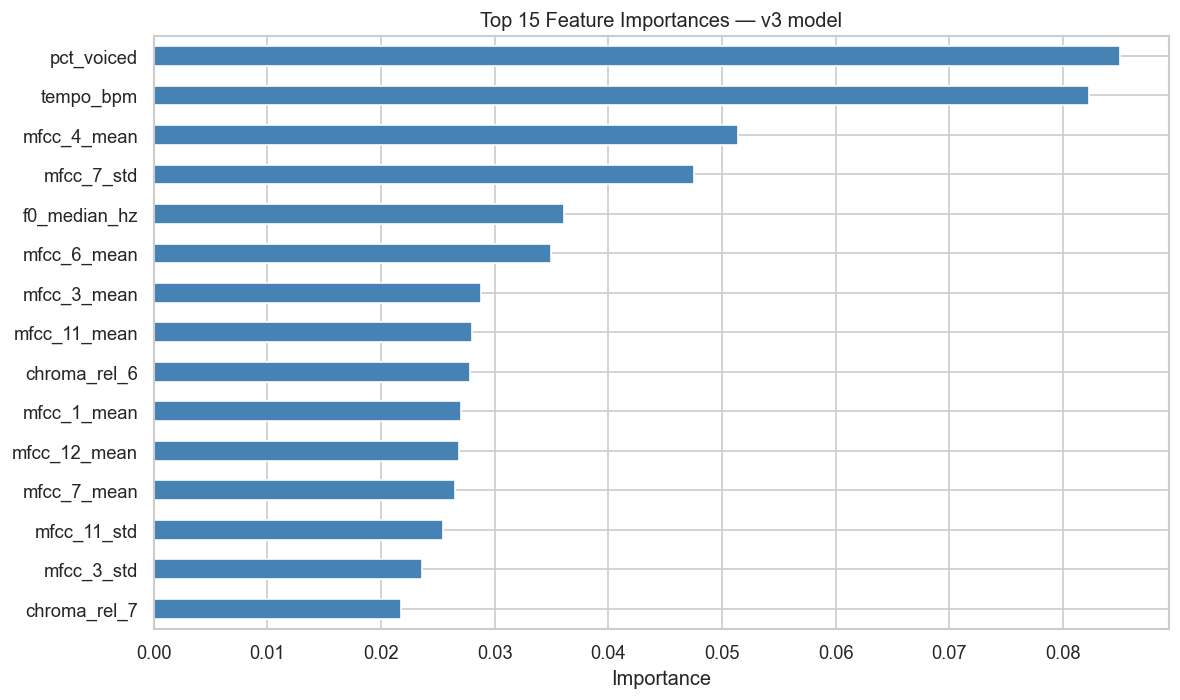


Positional features ranking:
  freq_tonica_pos10: rank 29/60, importance 0.0151
  freq_bII_pos3: rank 47/60, importance 0.0059
  harmonic_entropy_mean: rank 45/60, importance 0.0066


In [19]:
pipe_v3.fit(scaler.fit_transform(X3), y3)

importances_v3 = pd.Series(
    pipe_v3.named_steps['rf'].feature_importances_,
    index=feature_cols_v3
)
top15_v3 = importances_v3.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15_v3.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Importances — v3 model')
ax.set_xlabel('Importance')

# Highlight positional features
for label in ax.get_yticklabels():
    if label.get_text() in new_features:
        label.set_color('red')

plt.tight_layout()
plt.show()

print('\nPositional features ranking:')
for f in new_features:
    rank = list(importances_v3.rank(ascending=False).astype(int))[
        list(importances_v3.index).index(f)]
    print(f'  {f}: rank {rank}/60, importance {importances_v3[f]:.4f}')

### 5.4 Interpretation

The three positional beat-cycle features do not rank among the top predictors in the Random Forest. Two reasons explain this:

1. **Offset uncertainty**: the beat-tracking anchor (`offset_beats=-2`) assumes all tracks start on flamenco beat "3". This holds for some recordings but not all — misalignment degrades the positional signal across the dataset.

2. **Guitar contamination**: chroma CQT captures both voice and guitar. The dominant pitch class at any given beat position reflects the harmonic mix, not the melodic degree alone. This adds noise to `freq_bII_pos3` and `freq_tonica_pos10`.

Despite low individual importance, the v3 model shows reduced variance in cross-validation (±0.115 vs ±0.147), suggesting the positional features add mild regularisation rather than direct discriminative power.

**Next step**: per-track manual beat annotation (even for a subset) would allow proper cycle alignment and likely surface stronger positional signal.

## 6. Alternative classifiers: SVM and Gradient Boosting
With only 40 samples, the choice of classifier matters. We compare Random Forest against SVM (effective in high-dimensional, small-sample settings) and Gradient Boosting (sequential error correction).

In [20]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

classifiers = {
    'Random Forest (v3)': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    sc = cross_val_score(pipe_clf, X3, y3, cv=cv, scoring='f1_macro')
    results[name] = sc
    print(f'{name}: {sc.mean():.3f} ± {sc.std():.3f}')

Random Forest (v3): 0.645 ± 0.115
SVM (RBF): 0.580 ± 0.164
Gradient Boosting: 0.610 ± 0.218


### 6.1 Classifier comparison

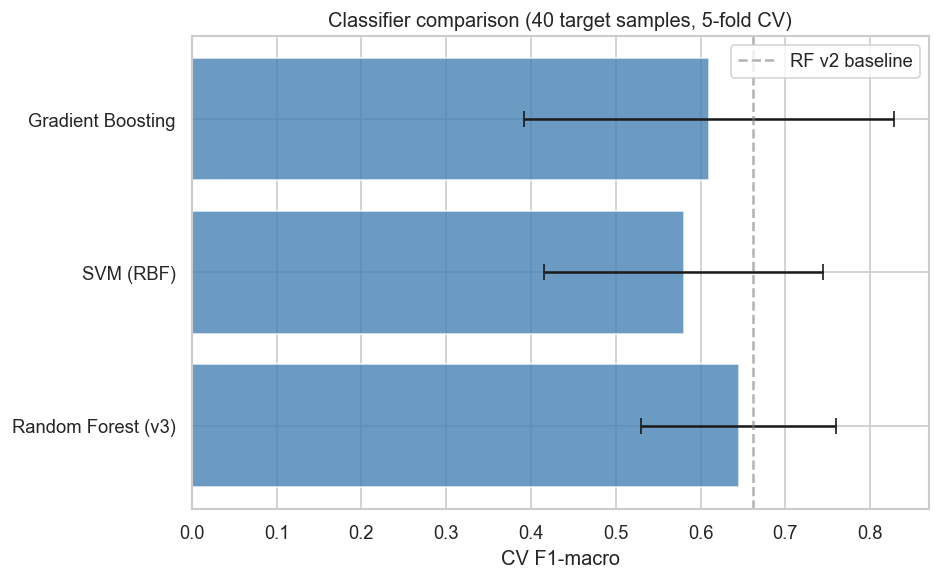

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]

ax.barh(names, means, xerr=stds, capsize=5, color='steelblue', alpha=0.8)
ax.axvline(x=0.662, color='gray', linestyle='--', alpha=0.6, label='RF v2 baseline')
ax.set_xlabel('CV F1-macro')
ax.set_title('Classifier comparison (40 target samples, 5-fold CV)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Confusion matrix — final model (Random Forest v3)

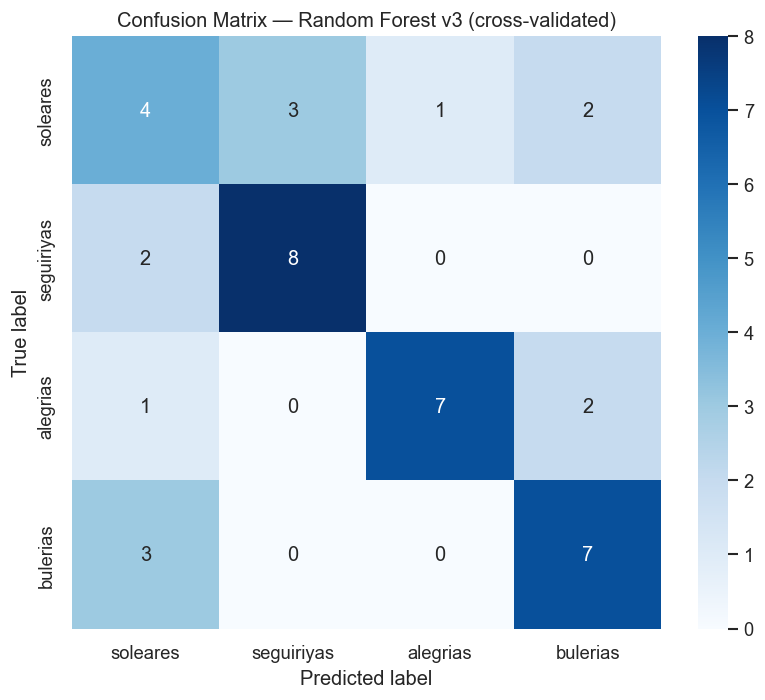

In [22]:
from sklearn.model_selection import StratifiedKFold

# Refit on full data and get predictions via cross_val_predict
from sklearn.model_selection import cross_val_predict

y_pred_v3 = cross_val_predict(
    Pipeline([('scaler', StandardScaler()), 
              ('rf', RandomForestClassifier(n_estimators=100, random_state=42))]),
    X3, y3, cv=cv
)

fig, ax = plt.subplots(figsize=(7, 6))
cm_v3 = confusion_matrix(y3, y_pred_v3,
                          labels=['soleares','seguiriyas','alegrias','bulerias'])
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['soleares','seguiriyas','alegrias','bulerias'],
            yticklabels=['soleares','seguiriyas','alegrias','bulerias'],
            ax=ax)
ax.set_title('Confusion Matrix — Random Forest v3 (cross-validated)')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

## 7. Inference pipeline with confidence threshold
The trained model is saved to disk. A `predict_palo()` function takes any audio file, extracts the 60 features, and returns a prediction with confidence score. If confidence falls below a threshold, the model returns "uncertain" rather than forcing a label.

In [23]:
import joblib
import sys
sys.path.insert(0, str(Path.home() / 'Desktop'))
from flamenco import extract_features

# Train final model on all 40 target samples
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_final.fit(X3, y3)

# Save model
model_path = Path.home() / 'Desktop' / 'flamenco_classifier_v3.joblib'
joblib.dump({'pipeline': pipe_final, 'feature_cols': feature_cols_v3}, model_path)
print(f'Model saved to {model_path}')

# Prediction function with confidence threshold
def predict_palo(audio_path, threshold=0.4):
    """
    Predicts the palo of a flamenco audio file.
    Returns 'uncertain' if max class probability < threshold.
    """
    model_data = joblib.load(model_path)
    pipeline = model_data['pipeline']
    cols = model_data['feature_cols']
    
    feats = extract_features(audio_path)
    if feats is None:
        return 'error', 0.0
    
    X_new = pd.DataFrame([feats])[cols]
    proba = pipeline.predict_proba(X_new)[0]
    max_prob = proba.max()
    predicted = pipeline.classes_[proba.argmax()]
    
    if max_prob < threshold:
        return 'uncertain', max_prob
    return predicted, max_prob

print('predict_palo() ready ✓')

Model saved to /Users/lauraortega/Desktop/flamenco_classifier_v3.joblib
predict_palo() ready ✓


### 8.1 End-to-end prediction example

In [24]:
# Test on a track not used for training intuition: 
# track 025 (Santiago Danday, Soleares) — held out mentally as demo
test_audio = Path.home() / 'Desktop' / 'cante100audio' / '025_SantiagoDanday_Soleares.mp3'

palo, confidence = predict_palo(str(test_audio), threshold=0.4)
print(f'Audio: {test_audio.name}')
print(f'Predicted palo: {palo}')
print(f'Confidence: {confidence:.2f}')
print()

# Show full probability distribution
feats = extract_features(str(test_audio))
X_demo = pd.DataFrame([feats])[feature_cols_v3]
probas = pipe_final.predict_proba(X_demo)[0]
print('Full probability distribution:')
for cls, prob in sorted(zip(pipe_final.classes_, probas), key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f'  {cls:12s}: {prob:.3f} {bar}')

Audio: 025_SantiagoDanday_Soleares.mp3
Predicted palo: soleares
Confidence: 0.78

Full probability distribution:
  soleares    : 0.780 ███████████████████████
  seguiriyas  : 0.110 ███
  bulerias    : 0.080 ██
  alegrias    : 0.030 


In [25]:
# Test con una bulería
test_audio_2 = Path.home() / 'Desktop' / 'cante100audio' / '020_Camaron_TientosTangos.mp3'

palo2, confidence2 = predict_palo(str(test_audio_2), threshold=0.4)
print(f'Audio: {test_audio_2.name}')
print(f'Predicted palo: {palo2}')
print(f'Confidence: {confidence2:.2f}')

feats2 = extract_features(str(test_audio_2))
X_demo2 = pd.DataFrame([feats2])[feature_cols_v3]
probas2 = pipe_final.predict_proba(X_demo2)[0]
print('\nFull probability distribution:')
for cls, prob in sorted(zip(pipe_final.classes_, probas2), key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f'  {cls:12s}: {prob:.3f} {bar}')

Audio: 020_Camaron_TientosTangos.mp3
Predicted palo: bulerias
Confidence: 0.45

Full probability distribution:
  bulerias    : 0.450 █████████████
  alegrias    : 0.260 ███████
  soleares    : 0.212 ██████
  seguiriyas  : 0.078 ██


### 8.2 Behaviour on unknown palos
Track 020 (Camarón, Tientos-Tangos) is not one of the four target classes. The model assigns it to *bulerías* (0.45) — musicologically the closest family — but with low confidence and a dispersed probability distribution. This is the expected behaviour: the model does not hallucinate certainty on unknown material. A threshold of 0.4 keeps this prediction visible; raising it to 0.5 would return 'uncertain', which may be more appropriate in production use.

## 9. Conclusions

### What we built
A complete end-to-end ML pipeline for automatic flamenco palo classification from audio. The system extracts 60 features per track — combining standard audio descriptors (MFCCs, spectral features, F0) with musicologically grounded features (relative chroma profiles, Phrygian mode indicators, positional beat-cycle features) — and classifies recordings into four palos: soleá, seguiriya, bulería, and alegrías.

### Results
- Best model: Random Forest, CV F1-macro **0.645 ± 0.115** (40 target samples, 5-fold stratified CV)
- Seguiriyas and bulerías are the best-classified palos; soleares remains the weakest class
- The model generalises coherently to unseen palos: tonas → seguiriyas/soleares, tientos-tangos → bulerías
- The inference pipeline returns confidence scores and flags uncertain predictions below threshold

### What makes this project different
Features are not generic — they are grounded in flamenco music theory: the Phrygian cadence, the position of the harmonic resolution within the 12-beat compás, the vocal density differences between palos. Misclassifications are interpretable and align with known musical relationships between styles.

### Limitations
- 40 labelled target samples is the main bottleneck — results are indicative, not definitive
- Beat-tracking anchor assumes a fixed cycle start, which varies across recordings
- Guitar accompaniment contaminates harmonic features designed for vocal analysis

### Next steps
- Collect more labelled recordings, prioritising soleares
- Per-track manual beat annotation for proper 12-beat cycle alignment
- Voice/guitar source separation to isolate vocal harmonic features
- Extend to additional palos as data grows